<a href="https://colab.research.google.com/github/monishabhojkumar12-avi/Aerial-Object-classification-and-detection/blob/main/FinalProject_DS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
browser_data=pd.read_csv("/content/browsing_history.csv")
domain_data=pd.read_csv("/content/domain_category_map.csv")
ram_data=pd.read_csv("/content/ram_log (2).csv")

In [2]:
browser_data.head()

,timestamp,url,domain,category,browser
0,2026-02-01 00:00:36,https://x.com/page74,x.com,social,chrome
1,2026-02-01 00:02:08,https://stackoverflow.com/page13,stackoverflow.com,learning,chrome
2,2026-02-01 00:03:14,https://github.com/page3,github.com,learning,chrome
3,2026-02-01 00:04:53,https://youtube.com/page5,youtube.com,video,chrome
4,2026-02-01 00:05:56,https://facebook.com/page68,facebook.com,social,chrome


In [3]:
domain_data.head()

,domain,category
0,instagram.com,social
1,facebook.com,social
2,x.com,social
3,reddit.com,social
4,youtube.com,video


In [4]:
ram_data.head()

,timestamp,ram_used_mb,ram_available_mb,browser_ram_mb
0,2026-02-01 00:00:00,5174.430775,10825.569225,957.297205
1,2026-02-01 00:00:05,7040.965254,8959.034746,1517.644377
2,2026-02-01 00:00:10,7345.085882,8654.914118,826.130730
3,2026-02-01 00:00:15,6711.599970,9288.400030,1171.846385
4,2026-02-01 00:00:20,6062.024951,9937.975049,617.513558


In [5]:
browser_data['timestamp'] = pd.to_datetime(browser_data['timestamp'])
ram_data['timestamp'] = pd.to_datetime(ram_data['timestamp'])

In [6]:
merged_df = pd.merge_asof(
    browser_data.sort_values('timestamp'),
    ram_data.sort_values('timestamp'),
    on='timestamp',
    direction='nearest'
)
merged_df.head()

,timestamp,url,domain,category,browser,ram_used_mb,ram_available_mb,browser_ram_mb
0,2026-02-01 00:00:36,https://x.com/page74,x.com,social,chrome,7297.078805,8702.921195,634.550154
1,2026-02-01 00:02:08,https://stackoverflow.com/page13,stackoverflow.com,learning,chrome,5996.921381,10003.078619,891.922551
2,2026-02-01 00:03:14,https://github.com/page3,github.com,learning,chrome,6538.321890,9461.678110,1183.595947
3,2026-02-01 00:04:53,https://youtube.com/page5,youtube.com,video,chrome,7900.443030,8099.556970,632.466125
4,2026-02-01 00:05:56,https://facebook.com/page68,facebook.com,social,chrome,7038.437277,8961.562723,1012.808236


In [7]:
merged_df[['timestamp','browser_ram_mb']]

,timestamp,browser_ram_mb
0,2026-02-01 00:00:36,634.550154
1,2026-02-01 00:02:08,891.922551
2,2026-02-01 00:03:14,1183.595947
3,2026-02-01 00:04:53,632.466125
4,2026-02-01 00:05:56,1012.808236
...,...,...
99995,2026-08-27 18:59:24,459.347461
99996,2026-08-27 19:00:18,1116.757234
99997,2026-08-27 19:02:07,485.208437
99998,2026-08-27 19:02:17,878.146311


In [52]:
merged_df.to_csv("merged_browser_ram.csv", index=False)

**Sessionization**

In [9]:
merged_df = merged_df.sort_values('timestamp')

merged_df['time_diff'] = merged_df['timestamp'].diff().dt.total_seconds() / 60

merged_df['new_session'] = (merged_df['time_diff'] > 15).astype(int) #15 min

merged_df['session_id'] = merged_df['new_session'].cumsum()

In [10]:
merged_df[['timestamp','session_id']]

,timestamp,session_id
0,2026-02-01 00:00:36,0
1,2026-02-01 00:02:08,0
2,2026-02-01 00:03:14,0
3,2026-02-01 00:04:53,0
4,2026-02-01 00:05:56,0
...,...,...
99995,2026-08-27 18:59:24,4933
99996,2026-08-27 19:00:18,4933
99997,2026-08-27 19:02:07,4933
99998,2026-08-27 19:02:17,4933


In [11]:
session_df = merged_df.groupby('session_id').agg({
    'timestamp': ['min', 'max'],
    'domain': 'count',
    'category': lambda x: x.mode()[0],
    'browser_ram_mb': ['mean', 'max'],
    'ram_used_mb': 'mean'
})

session_df.columns = [
    'start_time', 'end_time',
    'num_events',
    'dominant_category',
    'avg_browser_ram', 'peak_browser_ram',
    'avg_ram_used'
]

session_df['session_duration'] = (
    session_df['end_time'] - session_df['start_time']
).dt.total_seconds() / 60

session_df.reset_index(inplace=True)

session_df.to_csv("session_features.csv", index=False)

In [12]:
session_df.head()

,session_id,start_time,end_time,num_events,dominant_category,avg_browser_ram,peak_browser_ram,avg_ram_used,session_duration
0,0,2026-02-01 00:00:36,2026-02-01 00:10:37,9,learning,882.496244,1593.516061,6767.179008,10.016667
1,1,2026-02-01 01:02:37,2026-02-01 01:14:21,10,social,779.629551,1158.252159,6217.307296,11.733333
2,2,2026-02-01 02:01:21,2026-02-01 02:04:25,4,learning,967.225601,1640.718410,6177.372339,3.066667
3,3,2026-02-01 02:50:25,2026-02-01 04:18:44,83,video,966.943532,1950.419004,6581.222575,88.316667
4,4,2026-02-01 04:45:44,2026-02-01 04:54:36,9,social,718.859604,1035.268334,6391.652065,8.866667


In [13]:
def switching_rate(x):
    return (x != x.shift()).sum() / len(x)

switching = merged_df.groupby("session_id")["category"].apply(switching_rate)

session_df["switching_rate"] = switching

**Analysis**

In [14]:
merged_df['category'].value_counts()

,count
category,
learning,31470
video,24905
social,24904
shopping,12559
other,6162


In [15]:
merged_df['hour'] = merged_df['timestamp'].dt.hour
merged_df.groupby('hour').size()

,0
hour,
0,4185
1,4248
2,4128
3,4251
4,4148
5,4676
6,3941
7,4241
8,4205


In [16]:
session_df.columns

Index(['session_id', 'start_time', 'end_time', 'num_events',
       'dominant_category', 'avg_browser_ram', 'peak_browser_ram',
       'avg_ram_used', 'session_duration', 'switching_rate'],
      dtype='object')

In [51]:
features= session_df[[
    'session_duration',
    'num_events',
    'avg_browser_ram',
    'peak_browser_ram',
]]

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [25]:
from sklearn.cluster import KMeans

kmeans=KMeans(n_clusters=3,random_state=42)
session_df['cluster']=kmeans.fit_predict(scaled_features)

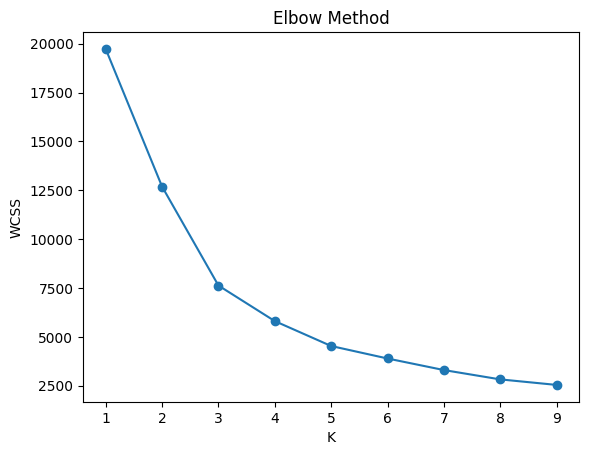

In [50]:
import matplotlib.pyplot as plt
wcss = []
K_range = range(1, min(10, len(scaled_features)+1))

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)


plt.plot(K_range, wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("WCSS")
plt.show()

In [53]:
from sklearn.metrics import silhouette_score

score = silhouette_score(scaled_features, kmeans.labels_)

print("Silhouette Score:", score)


Silhouette Score: 0.3225350420254558


In [54]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_features)

    score = silhouette_score(scaled_features, labels)
    scores.append(score)

    print(f"K={k}, Silhouette Score={score:.4f}")

K=2, Silhouette Score=0.3751
K=3, Silhouette Score=0.4340
K=4, Silhouette Score=0.4050
K=5, Silhouette Score=0.3885
K=6, Silhouette Score=0.3546
K=7, Silhouette Score=0.3313
K=8, Silhouette Score=0.3324
K=9, Silhouette Score=0.3182


In [27]:
session_df.groupby('cluster')[[
    'session_duration',
    'num_events',
    'avg_browser_ram',
    'peak_browser_ram',
]].mean()

,session_duration,num_events,avg_browser_ram,peak_browser_ram
cluster,,,,
0,15.877074,15.714961,983.986472,1802.008598
1,4.986705,5.566992,782.395928,1029.134651
2,59.401812,55.784870,928.781054,1923.077963


In [30]:
def label_cluster(row):
   if row['cluster']==1:
      return "short casual session"
   elif row['cluster']==1:
      return "heavy usage session"
   else :
      return "moderate session"
session_df['cluster_label']=session_df.apply(label_cluster,axis=1)

Ram **Analysis**

In [31]:
merged_df.groupby('category')['browser_ram_mb'].agg(['mean','max']).sort_values(by='mean', ascending=False)

,mean,max
category,,
shopping,933.556084,1999.992174
other,931.838805,1999.253194
social,931.124320,1999.959480
learning,928.581569,1999.985973
video,927.471772,1999.987791


In [32]:
session_df.groupby('cluster')[['avg_browser_ram','peak_browser_ram']].mean()

,avg_browser_ram,peak_browser_ram
cluster,,
0,983.986472,1802.008598
1,782.395928,1029.134651
2,928.781054,1923.077963


Time based **Analysis**

<Axes: xlabel='hour'>

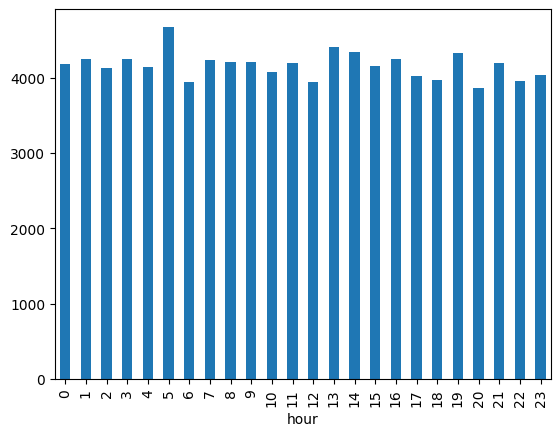

In [33]:

merged_df['hour'] = pd.to_datetime(merged_df['timestamp']).dt.hour

merged_df.groupby('hour').size().plot(kind='bar')

In [34]:

late_night = merged_df[merged_df['hour'] >= 22]
late_night['category'].value_counts()

,count
category,
learning,2549
video,1982
social,1974
shopping,1025
other,471


Behavior **Analysis**

In [35]:
session_df.sort_values('session_duration', ascending=False).head(10)

,session_id,start_time,end_time,num_events,dominant_category,avg_browser_ram,peak_browser_ram,avg_ram_used,session_duration,switching_rate,cluster,cluster_label
3234,3234,2026-06-16 22:05:07,2026-06-17 01:40:08,196,learning,959.220168,1963.398153,6497.431913,215.016667,0.693878,2,moderate session
4330,4330,2026-08-02 09:41:32,2026-08-02 12:29:11,165,learning,885.734604,1950.374338,6449.806729,167.650000,0.793939,2,moderate session
1805,1805,2026-04-18 01:58:56,2026-04-18 04:35:45,154,learning,920.525543,1987.125978,6515.223096,156.816667,0.766234,2,moderate session
1938,1938,2026-04-23 20:35:51,2026-04-23 23:09:28,146,video,914.055774,1998.997239,6493.608893,153.616667,0.794521,2,moderate session
647,647,2026-02-28 10:51:07,2026-02-28 13:21:35,139,learning,873.971791,1978.413391,6376.155094,150.466667,0.791367,2,moderate session
1075,1075,2026-03-18 16:38:27,2026-03-18 19:07:48,145,social,899.666765,1986.998905,6457.780534,149.350000,0.806897,2,moderate session
3879,3879,2026-07-14 11:32:38,2026-07-14 14:01:47,145,learning,919.822130,1998.793866,6580.792006,149.150000,0.751724,2,moderate session
2474,2474,2026-05-16 03:14:09,2026-05-16 05:42:24,137,learning,938.446143,1944.711583,6352.582047,148.250000,0.759124,2,moderate session
2827,2827,2026-05-31 02:35:04,2026-05-31 05:02:10,134,learning,891.751687,1973.893291,6396.323047,147.100000,0.738806,2,moderate session
4098,4098,2026-07-24 02:30:21,2026-07-24 04:52:34,121,learning,952.245218,1991.328421,6501.040424,142.216667,0.793388,2,moderate session


In [36]:
session_df.sort_values('peak_browser_ram', ascending=False).head(10)

,session_id,start_time,end_time,num_events,dominant_category,avg_browser_ram,peak_browser_ram,avg_ram_used,session_duration,switching_rate,cluster,cluster_label
230,230,2026-02-11 01:00:53,2026-02-11 01:24:17,20,learning,956.327827,1999.992174,6603.702079,23.400000,0.700000,0,moderate session
3727,3727,2026-07-07 23:45:05,2026-07-08 01:08:30,76,video,886.222177,1999.987791,6477.119938,83.416667,0.723684,2,moderate session
687,687,2026-03-02 06:44:35,2026-03-02 07:31:21,40,social,882.501207,1999.985973,6404.635862,46.766667,0.825000,2,moderate session
4655,4655,2026-08-16 02:51:42,2026-08-16 03:39:55,37,social,919.450954,1999.959480,6551.800931,48.216667,0.810811,2,moderate session
3763,3763,2026-07-09 15:02:13,2026-07-09 15:27:48,20,learning,976.425204,1999.959066,6375.510637,25.583333,0.850000,0,moderate session
2353,2353,2026-05-11 08:44:13,2026-05-11 09:49:31,64,learning,873.214609,1999.936917,6341.244560,65.300000,0.718750,2,moderate session
2067,2067,2026-04-29 04:34:41,2026-04-29 05:01:48,23,learning,1022.330955,1999.923255,6345.388908,27.116667,0.826087,0,moderate session
2561,2561,2026-05-19 16:50:43,2026-05-19 17:00:04,11,learning,1101.643752,1999.906200,6360.659532,9.350000,0.818182,0,moderate session
562,562,2026-02-24 18:37:10,2026-02-24 19:16:43,46,video,1035.148513,1999.867693,6602.926776,39.550000,0.913043,2,moderate session
1395,1395,2026-03-31 18:01:42,2026-03-31 18:42:08,37,learning,972.098180,1999.854039,6607.769067,40.433333,0.702703,2,moderate session


In [37]:
recommendations = []

# Rule 1: High RAM category
top_ram_cat = merged_df.groupby('category')['browser_ram_mb'].mean().idxmax()
recommendations.append(f"{top_ram_cat} consumes highest RAM → reduce tabs")

# Rule 2: Late night usage
if (merged_df['hour'] >= 22).sum() > 0:
    recommendations.append("High late-night browsing → consider limiting usage after 10PM")

# Rule 3: Long sessions
if session_df['session_duration'].max() > 120:
    recommendations.append("Long sessions detected → take breaks to improve productivity")

# Rule 4: High switching
if session_df['num_events'].mean() > 50:
    recommendations.append("Frequent tab switching → reduce multitasking")

for r in recommendations:
    print("•", r)

• shopping consumes highest RAM → reduce tabs
• High late-night browsing → consider limiting usage after 10PM
• Long sessions detected → take breaks to improve productivity


In [38]:

merged_df.to_csv("merged_browser_ram.csv", index=False)

In [39]:
session_df.head()


,session_id,start_time,end_time,num_events,dominant_category,avg_browser_ram,peak_browser_ram,avg_ram_used,session_duration,switching_rate,cluster,cluster_label
0,0,2026-02-01 00:00:36,2026-02-01 00:10:37,9,learning,882.496244,1593.516061,6767.179008,10.016667,0.777778,0,moderate session
1,1,2026-02-01 01:02:37,2026-02-01 01:14:21,10,social,779.629551,1158.252159,6217.307296,11.733333,0.800000,1,short casual session
2,2,2026-02-01 02:01:21,2026-02-01 02:04:25,4,learning,967.225601,1640.718410,6177.372339,3.066667,0.750000,0,moderate session
3,3,2026-02-01 02:50:25,2026-02-01 04:18:44,83,video,966.943532,1950.419004,6581.222575,88.316667,0.795181,2,moderate session
4,4,2026-02-01 04:45:44,2026-02-01 04:54:36,9,social,718.859604,1035.268334,6391.652065,8.866667,0.888889,1,short casual session


In [40]:
session_df.to_csv("session_features.csv",index=False)

In [43]:
import pickle
with open("kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans, f)
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)